In [6]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.insert(0, r"../main_code/3d")
for _mod in ['generate_data', 'mesh', 'adaptive_int', 'visual', 'matrix_assemble', 'inverse_solver', 'mea_3d', 'net_3d', 'source_eval', 'error_general_3d', 'main', 'bound_detect', 'q_filter']:
    sys.modules.pop(_mod, None)
import generate_data,mesh,visual,matrix_assemble,inverse_solver,mea_3d,net_3d,source_eval,error_general_3d,main
CUDA_LAUNCH_BLOCKING=1

def f_y(x, x_min,x_max,y_min,y_max,z_min,z_max,center,r):
    r_y = np.linalg.norm(x - center, axis=-1) 
    
    # Apply the piecewise function
    f_y_values = np.where(r_y < r, r - r_y, 0.0)
    return f_y_values

def ana_S(x,x_min,x_max,y_min,y_max,z_min,z_max,a,b,r): # x is the data array; a and b are center coordinates
    return f_y(x,x_min,x_max,y_min,y_max,z_min,z_max,a,r)-f_y(x,x_min,x_max,y_min,y_max,z_min,z_max,b,r)

    

cuda:1


In [7]:
import numpy as np
import matplotlib.pyplot as plt
S_num_5=np.load("./noise=5%/S_num_0.010000000000000002.npy")
x = np.linspace(0, 1, 301)
y = np.linspace(0, 1, 301)
z = np.linspace(0, 1, 301)
X, Y, Z = np.meshgrid(x, y,z,indexing='ij')
samples=np.vstack((X.ravel(),Y.ravel(),Z.ravel())).T
center=np.array([[0.3,0.5,0.3],[0.5,0.5,0.8]])
r=0.15


In [8]:
YY,ZZ=np.meshgrid(y, z,indexing='ij')
XX,ZZ=np.meshgrid(x, z,indexing='ij')

In [9]:
reload(visual)

<module 'visual' from '/data1/hxw-b25/MA-RFM/Ex4.8/../main_code/3d/visual.py'>

Plot saved as ./noise=5%/visual/ex4.8_S_true_x1_mid.pdf


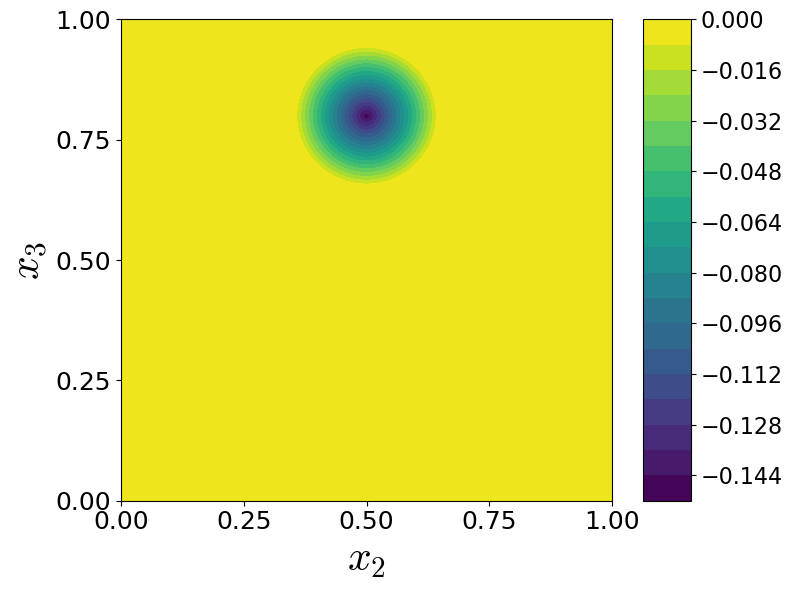

Plot saved as ./noise=5%/visual/ex4.8_S_num_x1_mid.pdf


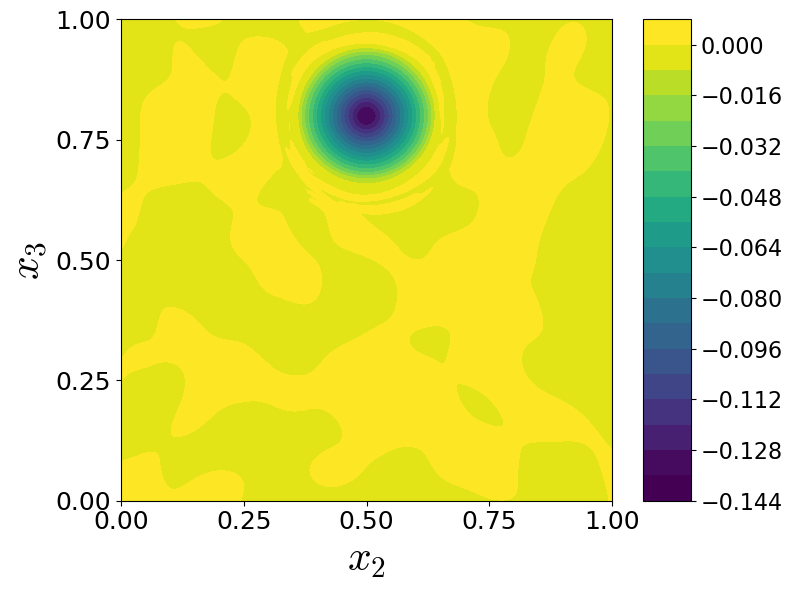

Plot saved as ./noise=5%/visual/ex4.8_S_true_x2_mid.pdf


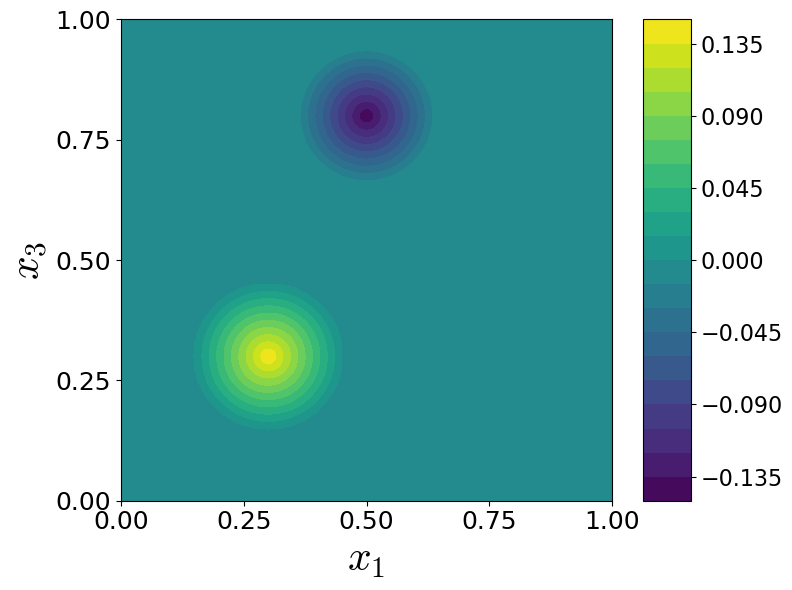

Plot saved as ./noise=5%/visual/ex4.8_S_num_x2_mid.pdf


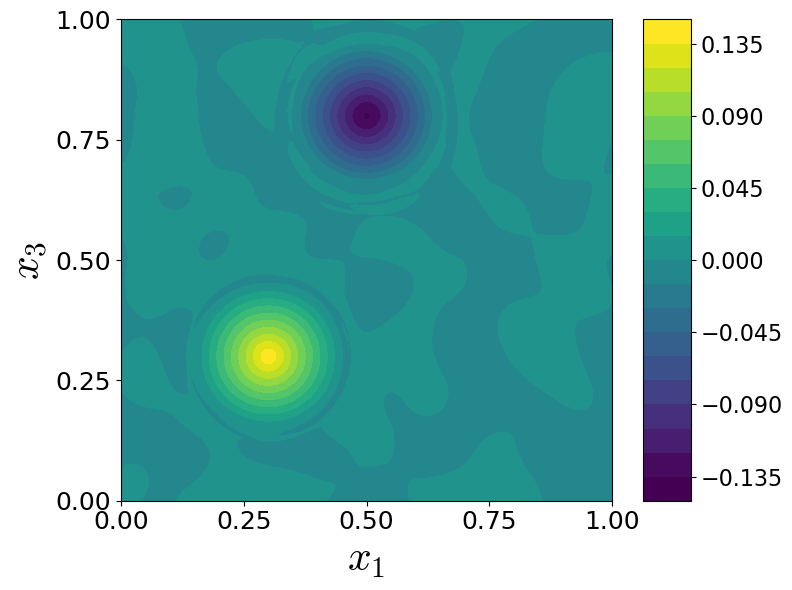

In [24]:
S_true=ana_S(samples,[],[],[],[],[],[],center[0],center[1],r).reshape(len(x),len(y),len(z))
ratio1=center[0]
ratio2=center[1]
S_num_x1_mid=S_num_5[int(0.5*S_num_5.shape[0])+1-1,:,:].reshape(len(y),len(z))
S_true_x1_mid=S_true[int(ratio1[1]*S_true.shape[1])+1-1,:,:].reshape(len(y),len(z))
S_num_x2_mid=S_num_5[:,int(0.5*S_num_5.shape[2])+1-1,:].reshape(len(y),len(z))
S_true_x2_mid=S_true[:,int(0.5*S_true.shape[2])+1-1,:].reshape(len(y),len(z))

output_dictionary="./noise=5%/visual/"
visual.draw(YY,ZZ,S_true_x1_mid,[],"$x_2$","$x_3$",[],"viridis",[0,0.25,0.5,0.75,1],[0,0.25,0.5,0.75,1],output_dictionary,"S_true_x1_mid.pdf","")
visual.draw(YY,ZZ,S_num_x1_mid,[],"$x_2$","$x_3$",[],"viridis",[0,0.25,0.5,0.75,1],[0,0.25,0.5,0.75,1],output_dictionary,"S_num_x1_mid.pdf","")
visual.draw(XX,ZZ,S_true_x2_mid,[],"$x_1$","$x_3$",[],"viridis",[0,0.25,0.5,0.75,1],[0,0.25,0.5,0.75,1],output_dictionary,"S_true_x2_mid.pdf","")
visual.draw(XX,ZZ,S_num_x2_mid,[],"$x_1$","$x_3$",[],"viridis",[0,0.25,0.5,0.75,1],[0,0.25,0.5,0.75,1],output_dictionary,"S_num_x2_mid.pdf","")

Plot saved as ./noise=5%/visual/ex4.8_abs_S_x1.pdf


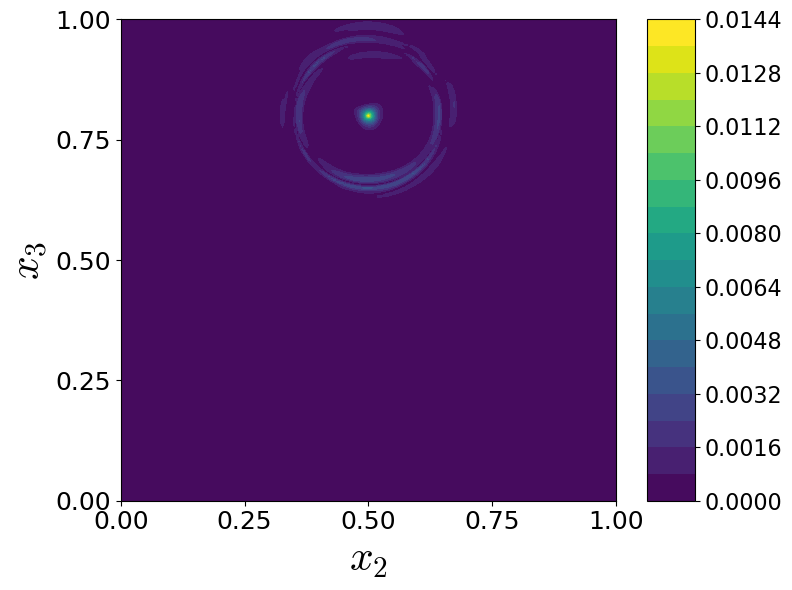

Plot saved as ./noise=5%/visual/ex4.8_abs_S_x2.pdf


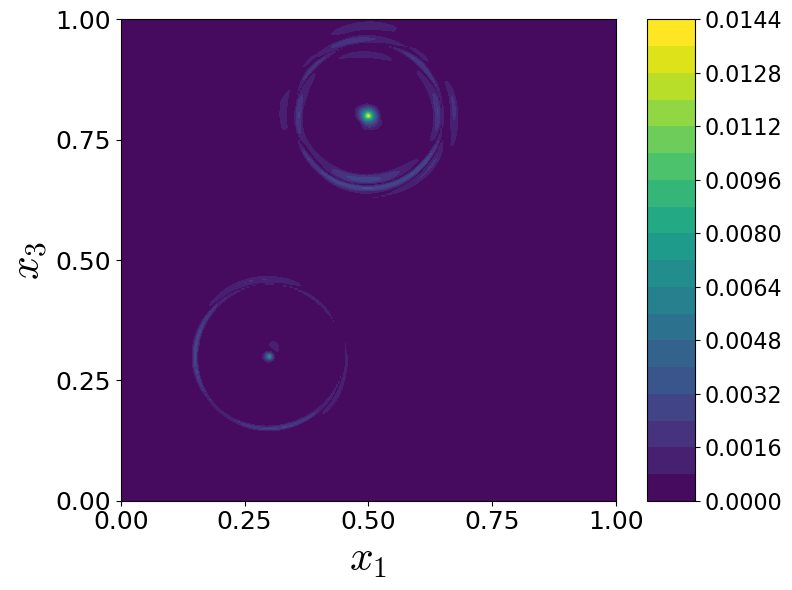

In [11]:
output_dictionary="./noise=5%/visual/"
visual.draw(YY,ZZ,np.abs(S_true_x1_mid-S_num_x1_mid),[],"$x_2$","$x_3$",[],"viridis",[0,0.25,0.5,0.75,1],[0,0.25,0.5,0.75,1],output_dictionary,"abs_S_x1.pdf"," ")
visual.draw(YY,ZZ,np.abs(S_true_x2_mid-S_num_x2_mid),[],"$x_1$","$x_3$",[],"viridis",[0,0.25,0.5,0.75,1],[0,0.25,0.5,0.75,1],output_dictionary,"abs_S_x2.pdf"," ")

In [13]:
S_num_store=np.load("./noise=5%/S_num_store.npy")
S_num_last=S_num_store[-1]
x_101 = np.linspace(0, 1, 101)
y_101 = np.linspace(0, 1, 101)
YY_101,ZZ_101=np.meshgrid(x_101, y_101,indexing='ij')

Plot saved as ./noise=5%/visual/ex4.8_S_num_x1_mid_ada.pdf
Plot saved as ./noise=5%/visual/ex4.8_S_num_1D_x2.pdf


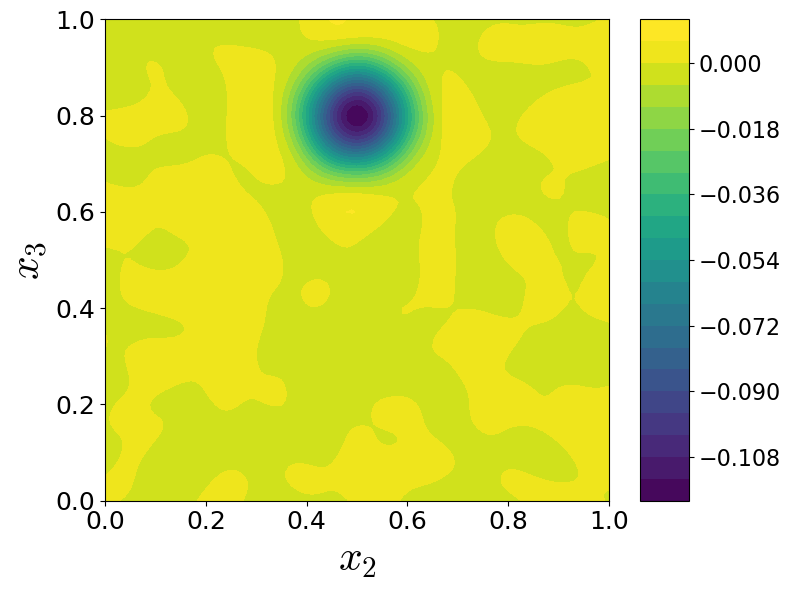

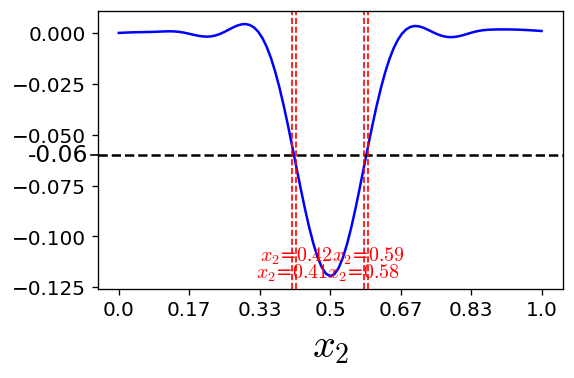

Plot saved as ./noise=5%/visual/ex4.8_S_num_x2_mid_ada.pdf
Plot saved as ./noise=5%/visual/ex4.8_S_num_1D_x1.pdf


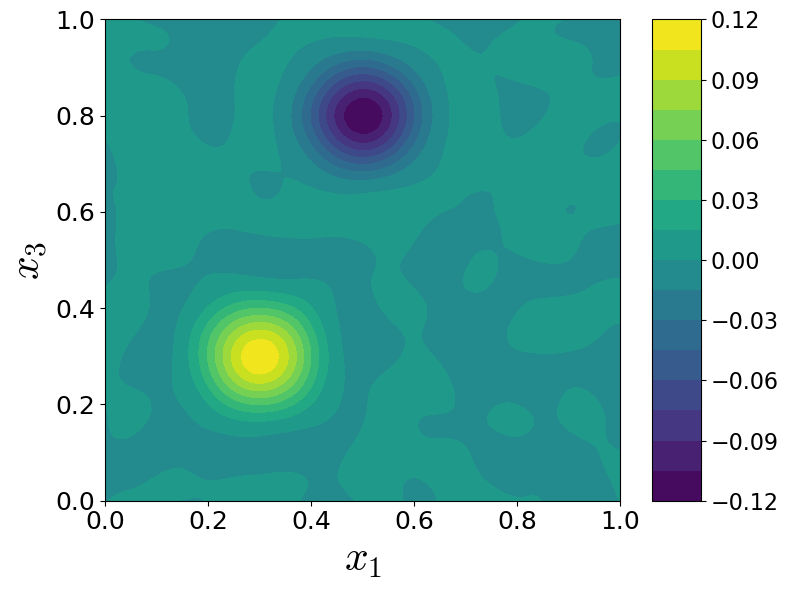

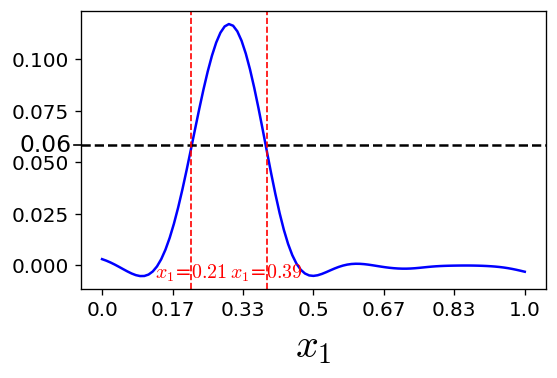

Plot saved as ./noise=5%/visual/ex4.8_S_num_x2_mid_ada.pdf
Plot saved as ./noise=5%/visual/ex4.8_S_num_1D_x3.pdf


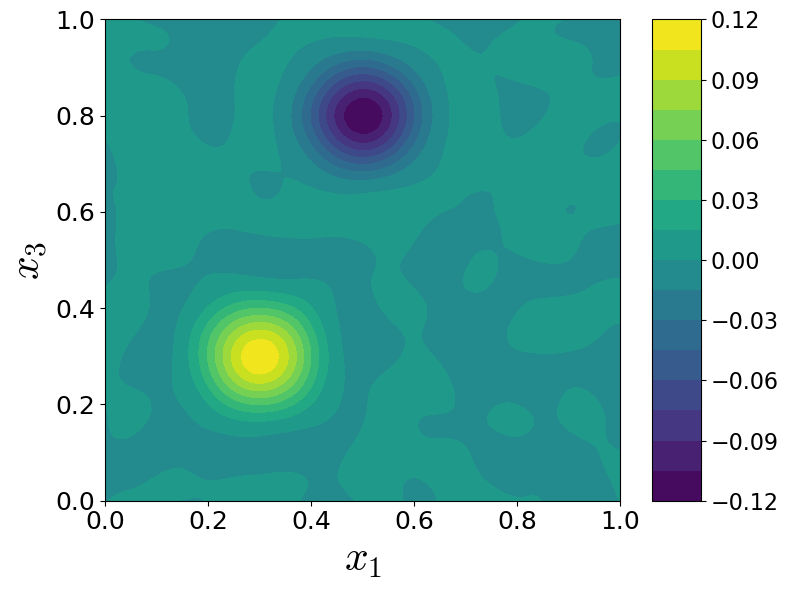

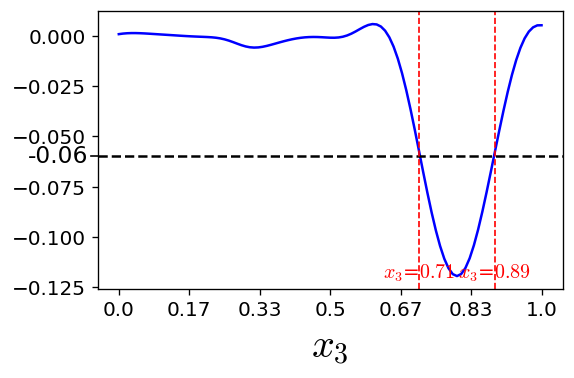

In [34]:
reload(visual)
S_num_x1_mid_ada=S_num_last[int(0.5*S_num_last.shape[0])+1-1,:,:].reshape(101,101)
S_num_x2_mid_ada=S_num_last[:,int(0.5*S_num_last.shape[2])+1-1,:].reshape(101,101)
S_num_1D_x1=S_num_last[:,int(ratio1[1]*S_num_last.shape[1])+1-1,int(ratio1[2]*S_num_last.shape[2])+1-1]
S_num_1D_x2=S_num_last[int(ratio2[0]*S_num_last.shape[0])+1-1,:,int(ratio2[2]*S_num_last.shape[2])+1-1]
S_num_1D_x3=S_num_last[int(ratio2[0]*S_num_last.shape[0])+1-1,int(ratio2[1]*S_num_last.shape[1])+1-1,:]
visual.draw(YY_101,ZZ_101,S_num_x1_mid_ada,S_num_1D_x2,"$x_2$","$x_3$","$x_2$",output_directory=output_dictionary,output_filename1="S_num_x1_mid_ada.pdf",output_filename2="S_num_1D_x2.pdf",temp_v=True)
visual.draw(YY_101,ZZ_101,S_num_x2_mid_ada,S_num_1D_x1,"$x_1$","$x_3$","$x_1$",output_directory=output_dictionary,output_filename1="S_num_x2_mid_ada.pdf",output_filename2="S_num_1D_x1.pdf",temp_v=True)
visual.draw(YY_101,ZZ_101,S_num_x2_mid_ada,S_num_1D_x3,"$x_1$","$x_3$","$x_3$",output_directory=output_dictionary,output_filename1="S_num_x2_mid_ada.pdf",output_filename2="S_num_1D_x3.pdf",temp_v=True)

In [60]:
g_S=np.load("./noise=5%/g_S.npy")
S_num_store=np.load("./noise=5%/S_num_store.npy")


def center_from_results_or_q_clusters(grad, S_num, domain_min, domain_max, para_grad, para_abs, result_name="results", eps=None, min_samples=20):
    detected_results = globals().get(result_name)
    if detected_results:
        return np.vstack([item["params"]["center"] for item in detected_results])

    grad_arr = np.asarray(grad)
    s_arr = np.asarray(S_num)
    if grad_arr.shape != s_arr.shape:
        raise ValueError(f"grad shape {grad_arr.shape} does not match S_num shape {s_arr.shape}")

    grad_threshold = np.max(grad_arr) / para_grad
    abs_threshold = np.max(np.abs(s_arr)) / para_abs
    mask = (grad_arr > grad_threshold) & (np.abs(s_arr) > abs_threshold)
    mask_indices = np.array(np.where(mask)).T
    if len(mask_indices) == 0:
        raise ValueError("No Q points detected; adjust para_grad/para_abs.")

    domain_min = np.asarray(domain_min, dtype=float)
    domain_max = np.asarray(domain_max, dtype=float)
    scales = (domain_max - domain_min) / (np.asarray(grad_arr.shape, dtype=float) - 1)
    q_points = domain_min + mask_indices * scales

    if eps is None:
        h = float(np.max(scales))
        eps = 5.0 * h

    try:
        from sklearn.cluster import DBSCAN
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit(q_points).labels_
        centers = []
        for label in sorted(set(labels)):
            if label == -1:
                continue
            cluster_points = q_points[labels == label]
            if len(cluster_points) > 0:
                centers.append(cluster_points.mean(axis=0))
        if centers:
            return np.vstack(centers)
    except Exception as exc:
        print(f"DBSCAN center fallback failed: {exc}")

    return np.atleast_2d(q_points.mean(axis=0))


Global volume range: [0.000, 1.000], using level=0.500


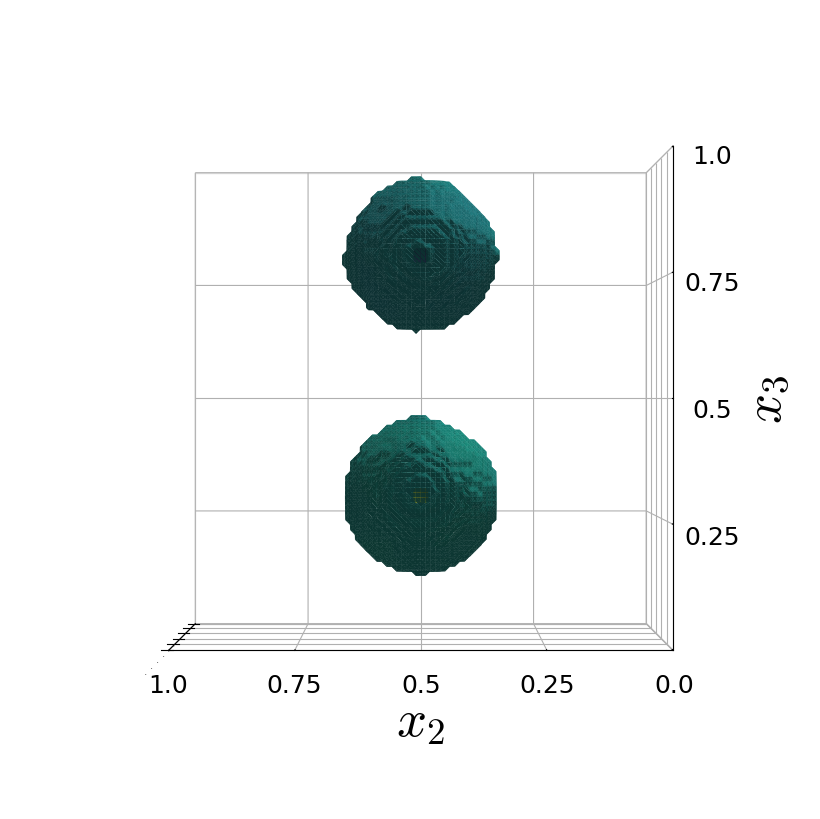

In [61]:
import visual
reload(visual)
dpi=100

center = center_from_results_or_q_clusters(g_S, S_num_store[-1], [0,0,0], [1,1,1], 3, 100)
ticks = [0.0, 0.25, 0.5, 0.75, 1]

mapped_mask_points,min_x_point,max_x_point,min_y_point,max_y_point,min_z_point,max_z_point = visual.detect_3d(
    g_S, S_num_store[-1],
    [0,0,0], [1,1,1],
    3, 100,
    0, 180, center, "S", "x1",
    output_directory="./noise=5%/visual",
    output_filename="plot_3d_straight.pdf",
    dpi=dpi,
    render_mode="surface_only",
    show_colorbar=False,
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    zlabel=r"$x_3$",
    x_ticks=ticks,
    y_ticks=ticks,
    z_ticks=ticks,
    axis_label_size=38,
    x_tick_pad=8,
    y_tick_pad=5,
    z_tick_pad=14,
    x_label_pad=15,
    y_label_pad=18,
    z_label_pad=30,
    axis_tick_size=18,
    hide_duplicate_corner_ticks=True,
    surface_stride=1,
    surface_rasterized=True,
)



Global volume range: [0.000, 1.000], using level=0.500


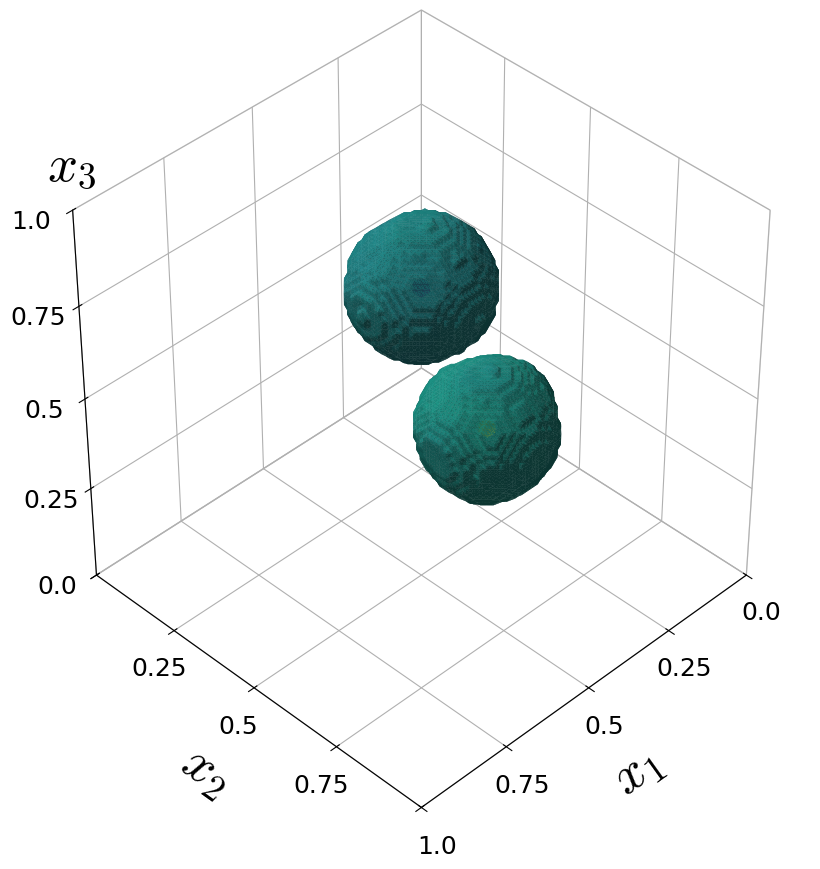

In [62]:
import visual
reload(visual)
dpi=100

center = center_from_results_or_q_clusters(g_S, S_num_store[-1], [0,0,0], [1,1,1], 3, 100)
ticks = [0.0, 0.25, 0.5, 0.75, 1.0]

mapped_mask_points,min_x_point,max_x_point,min_y_point,max_y_point,min_z_point,max_z_point = visual.detect_3d(
    g_S, S_num_store[-1],
    [0,0,0], [1,1,1],
    3, 100,
    40, 45, center, "S", None,
    output_directory="./noise=5%/visual",
    output_filename="plot_3d_tily.pdf",
    dpi=dpi,
    render_mode="surface_only",
    show_colorbar=False,
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    zlabel=r"$x_3$",
    x_ticks=ticks,
    y_ticks=ticks,
    z_ticks=ticks,
    x_tick_pad=6,
    y_tick_pad=6,
    z_tick_pad=10,
    x_label_pad=22,
    y_label_pad=22,
    z_label_pad=25,
    zlabel_position="axis_top",
    axis_label_size=38,
    axis_tick_size=18,
    hide_duplicate_corner_ticks=True,
    surface_stride=1,
    surface_rasterized=True,
)

Global volume range: [0.000, 1.000], using level=0.500


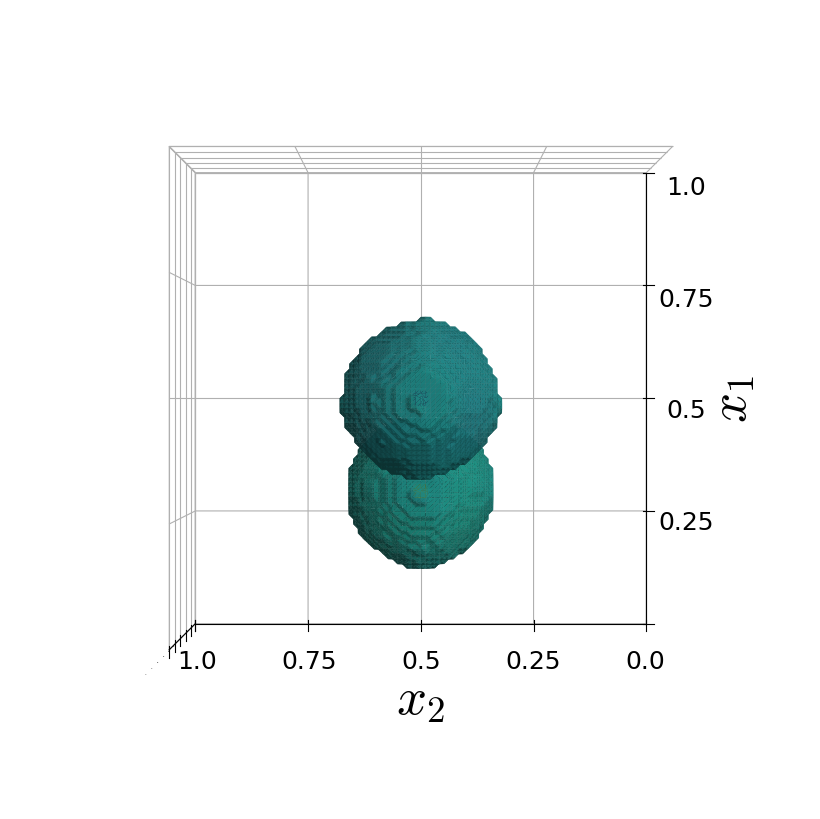

In [63]:
import visual
reload(visual)
dpi=100

center = center_from_results_or_q_clusters(g_S, S_num_store[-1], [0,0,0], [1,1,1], 3, 100)
ticks = [0.0, 0.25, 0.5, 0.75, 1.0]

mapped_mask_points,min_x_point,max_x_point,min_y_point,max_y_point,min_z_point,max_z_point = visual.detect_3d(
    g_S, S_num_store[-1],
    [0,0,0], [1,1,1],
    3, 100,
    90, 180, center, "S", "x3",
    output_directory="./noise=5%/visual",
    output_filename="plot_3d_top.pdf",
    dpi=dpi,
    render_mode="surface_only",
    show_colorbar=False,
    xlabel=r"$x_1$",
    ylabel=r"$x_2$",
    zlabel=r"$x_3$",
    x_ticks=ticks,
    y_ticks=ticks,
    z_ticks=ticks,
    axis_label_size=38,
    x_tick_pad=20,
    y_tick_pad=10,
    z_tick_pad=8,
    x_label_pad=40,
    y_label_pad=32,
    z_label_pad=25,
    axis_tick_size=18,
    hide_duplicate_corner_ticks=True,
    surface_stride=1,
    surface_rasterized=True,
)
